# Getting started: a surface-code memory, from circuit to logical error rate

This tutorial walks the whole path once: write a noisy circuit, look at it, build its
detector error model, sample it, decode it, and measure how often the decoder fails. Then
it sweeps distance and noise to find the threshold.

Everything here runs in `stabilizer_qec` alone. Where Stim is installed, the tutorial also
checks that the circuit, the error model and Stim's agree.

In [1]:
import numpy as np
import stabilizer_qec as sq

print(sq.__version__)

1.4.0


## 1. A circuit

`Circuit.generated` writes Stim's generated memory experiments, character for character
as `stim.Circuit.generated` does. This one is a distance-3 rotated surface code holding a
logical |0⟩ for 3 rounds. Every Clifford gate is followed by depolarizing noise, and every
measurement can flip.

In [2]:
circuit = sq.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=3,
    rounds=3,
    after_clifford_depolarization=0.001,
    before_measure_flip_probability=0.001,
)
print(circuit.num_qubits, "qubits,", circuit.num_detectors, "detectors,", circuit.num_observables, "observable")
print("\n".join(str(circuit).splitlines()[17:28]), "\n...")

26 qubits, 24 detectors, 1 observable
R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
TICK
H 2 11 16 25
DEPOLARIZE1(0.001) 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
DEPOLARIZE2(0.001) 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
DEPOLARIZE2(0.001) 2 1 16 15 11 10 8 14 3 9 12 18
TICK 
...


Detectors are parities of measurements that are deterministic without noise. A *detector
slice* shows what each one compares at a given moment. After the sixth `TICK`, the Z-type
plaquettes (blue) and the X-type plaquettes (red) of the code appear:

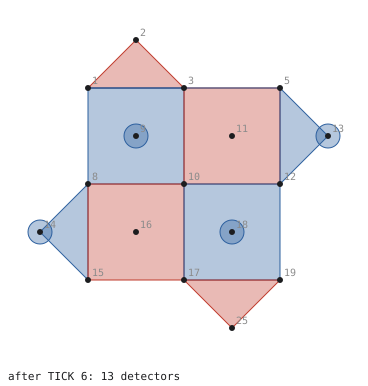

In [3]:
circuit.diagram("detslice-svg", tick=6)

The timeline shows every operation in its column, loops drawn once with their count. A
distance-3 repetition code over three rounds fits on a screen:

In [4]:
print(sq.Circuit.generated("repetition_code:memory", distance=3, rounds=3).diagram("timeline-text"))

                                              /REP 2--------------------------------------\
                                                  /---------------------------------------\ /---------------------------------------------\
q0: -R-@--------------------------------------@---------------------------------------------M:rec[6]-DETECTOR(1, 1):D6=rec[7]*rec[6]*rec[4]-
       |                                      |
q1: -R-X-X-MR:rec[0]-DETECTOR(1, 0):D0=rec[0]-X-X-MR:rec[2]-DETECTOR(1, 0):D2=rec[2]*rec[0]-------------------------------------------------
         |                                      |
q2: -R-@-@------------------------------------@-@-------------------------------------------M:rec[7]-DETECTOR(3, 1):D7=rec[8]*rec[7]*rec[5]-
       |                                      |
q3: -R-X-X-MR:rec[1]-DETECTOR(3, 0):D1=rec[1]-X-X-MR:rec[3]-DETECTOR(3, 0):D3=rec[3]*rec[1]-------------------------------------------------
         |                                      |
q4: -R--

## 2. The detector error model

Each independent fault in the circuit flips some detectors and perhaps the observable. The
*detector error model* lists them with their probabilities. Decomposed, every fault is
split into pieces of at most two detectors, which matching needs.

In [5]:
dem = circuit.detector_error_model(decompose_errors=True)
print(dem.num_errors, "faults over", dem.num_detectors, "detectors")
print("\n".join(str(dem).splitlines()[:6]))

286 faults over 24 detectors
error(0.0002667378157289138) D0
error(0.0002667378157289138) D0 D1
error(0.001266204340097456) D0 D8
error(0.0002667378157289138) D1 D2
error(0.001399253250337028) D1 D5
error(0.0001333866998761608) D1 D5 ^ D4


## 3. Sampling and decoding

The sampler draws shots of detection events and the true observable flips. The matcher
predicts the observable from the detection events alone; a shot fails when the prediction
is wrong.

In [6]:
sampler = circuit.compile_detector_sampler(seed=1)
dets, obs = sampler.sample(100_000, separate_observables=True)
print("detection events per shot:", dets.sum(axis=1).mean())

decoder = sq.Matching(dem)
predicted = decoder.decode_batch(dets)
failures = (predicted != obs).any(axis=1)
print(f"logical error rate: {failures.mean():.2e} ({failures.sum()} of {len(failures)} shots)")

detection events per shot: 0.20555
logical error rate: 2.50e-04 (25 of 100000 shots)


## 4. Finding the threshold

Below threshold, a larger code fails less often; above it, more. Sweeping three distances
over a range of noise strengths shows the curves crossing.

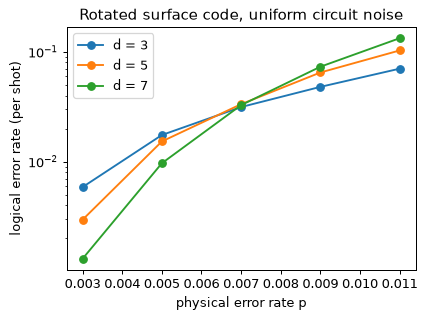

Text(0.5, 1.0, 'Rotated surface code, uniform circuit noise')

In [7]:
import matplotlib.pyplot as plt


def logical_error_rate(d, p, shots):
    c = sq.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=d,
        rounds=d,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )
    m = sq.Matching(c.detector_error_model(decompose_errors=True))
    dets, obs = c.compile_detector_sampler(seed=7).sample(shots, separate_observables=True)
    return (m.decode_batch(dets) != obs).any(axis=1).mean()


ps = [0.003, 0.005, 0.007, 0.009, 0.011]
fig, ax = plt.subplots(figsize=(5, 3.5))
for d in (3, 5, 7):
    rates = [logical_error_rate(d, p, 20_000) for p in ps]
    ax.plot(ps, rates, "o-", label=f"d = {d}")
ax.set_xlabel("physical error rate p")
ax.set_ylabel("logical error rate (per shot)")
ax.set_yscale("log")
ax.legend()
ax.set_title("Rotated surface code, uniform circuit noise")

The curves cross near p = 0.7%, the circuit-level threshold of the surface code under this
noise model (every operation noisy at strength p). Below it, each step up in distance
divides the logical error rate; above it, larger codes only collect more errors.

## 5. Agreement with Stim

Where Stim is installed, its circuit and its error model are the same text as these:

In [8]:
try:
    import stim
except ImportError:
    print("Stim is not installed; skipping the comparison.")
else:
    theirs = stim.Circuit.generated(
        "surface_code:rotated_memory_z", distance=3, rounds=3,
        after_clifford_depolarization=0.001, before_measure_flip_probability=0.001,
    )
    print("same circuit text:", str(circuit) == str(theirs) + "\n")
    print("same error model text:", str(dem) == str(theirs.detector_error_model(decompose_errors=True)) + "\n")

same circuit text: True
same error model text: True


Next: [decoders and real-time decoding](02_decoders.ipynb), and
[codes beyond the surface code](03_beyond_the_surface_code.ipynb).